# Baseline: bTMB ≥ 16 as a predictive biomarker

Establishes the evaluation harness that every downstream model (including the PBMF ensemble in later notebooks) will plug into, and measures the bTMB-only cutoff that PBMF claims to improve on.

A biomarker is **predictive** (not just prognostic) if the treatment effect differs between B+ and B- patients. Concretely:

- HR(Atezo vs Docetaxel | B+) should be << 1 (atezo benefits B+ patients strongly)
- HR(Atezo vs Docetaxel | B-) should be ≈ 1 (no differential benefit)
- Ratio HR+/HR- is the predictive signal; interaction p-value tests it formally

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pbmf import build_features, evaluate_biomarker, plot_km_strata

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3g}")

feat, genes = build_features()
print(f"BEP patients: {len(feat)}")
print(f"Top-20 genes: {genes}")
feat.head()

/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jaschabeste/repositories/pbmf-reproduction/pbmf/data.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.read_excel(xlsx_path, sheet_name=sheet).replace({".": np.nan})


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jaschabeste/repositories/pbmf-reproduction/pbmf/data.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.read_excel(xlsx_path, sheet_name=sheet).replace({".": np.nan})


BEP patients: 853
Top-20 genes: ['TP53', 'LRP1B', 'DNMT3A', 'SPTA1', 'FAT3', 'KEAP1', 'NF1', 'MLL2', 'STAG2', 'FAT1', 'TSC1', 'MLL3', 'ATM', 'EGFR', 'SMARCA4', 'EPHA6', 'PTPRD', 'KRAS', 'TET2', 'EPHA5']


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,PtID,Trial,TRT01P,OS,OS_event,PFS,PFS_event,age,sex_M,ecog,...,mut_TSC1,mut_MLL3,mut_ATM,mut_EGFR,mut_SMARCA4,mut_EPHA6,mut_PTPRD,mut_KRAS,mut_TET2,mut_EPHA5
0,282,POPLAR,Docetaxel,2.86,1,2.86,1,72,1,1,...,0,0,0,0,0,0,0,0,0,0
1,24,POPLAR,Atezolizumab,9.49,1,1.45,1,67,0,1,...,1,1,0,1,0,0,0,0,0,0
2,170,POPLAR,Atezolizumab,11.1,1,1.41,1,60,1,1,...,0,0,0,0,0,0,0,0,0,0
3,265,POPLAR,Atezolizumab,3.15,1,1.41,1,67,1,0,...,0,1,0,0,0,0,0,0,0,0
4,4,POPLAR,Atezolizumab,10.9,1,6.74,1,71,1,1,...,0,0,0,0,0,0,0,0,0,0


## bTMB ≥ 16 cutoff, per trial

In [2]:
feat["btmb_ge16"] = (feat["btmb"] >= 16).astype(int)

rows = []
for trial in ["POPLAR", "OAK"]:
    sub = feat[feat["Trial"] == trial]
    res = evaluate_biomarker(sub, label_col="btmb_ge16")
    row = res.as_series()
    row.name = trial
    rows.append(row)
pd.DataFrame(rows)

,n_B+,n_B-,HR(Tx|B+),CI(Tx|B+),p(Tx|B+),HR(Tx|B-),CI(Tx|B-),p(Tx|B-),HR+/HR-,p(interaction)
POPLAR,63,148,0.556,"[0.31, 0.99]",0.0478,0.762,"[0.52, 1.12]",0.162,0.73,0.342
OAK,160,482,0.622,"[0.43, 0.90]",0.0121,0.679,"[0.55, 0.84]",0.000344,0.917,0.502


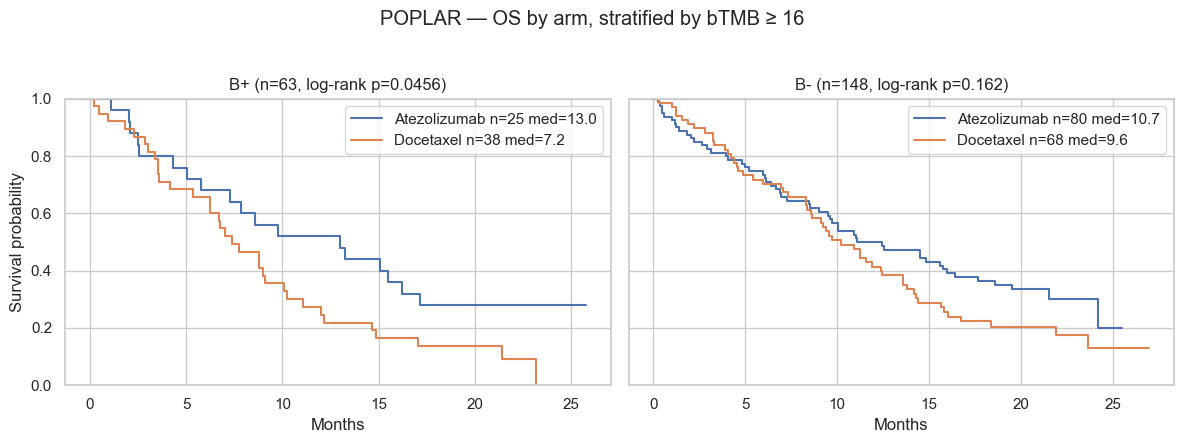

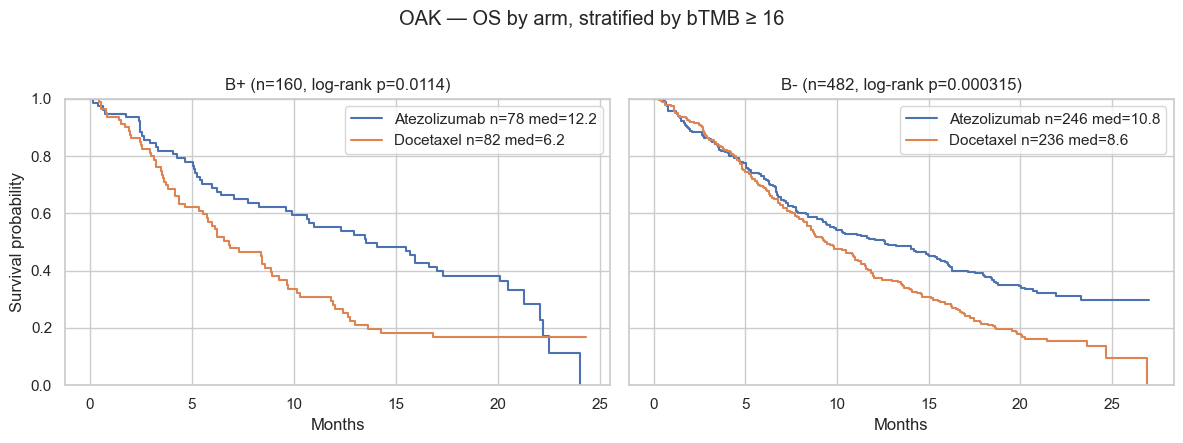

In [3]:
for trial in ["POPLAR", "OAK"]:
    sub = feat[feat["Trial"] == trial]
    plot_km_strata(sub, label_col="btmb_ge16",
                   title=f"{trial} — OS by arm, stratified by bTMB ≥ 16")
    plt.show()

## Cutoff sweep

Grid over candidate bTMB cutoffs on OAK (the larger cohort) to see how the predictive signal changes.

In [4]:
oak = feat[feat["Trial"] == "OAK"].copy()

rows = []
for cut in [6, 8, 10, 12, 14, 16, 18, 20]:
    oak[f"btmb_ge{cut}"] = (oak["btmb"] >= cut).astype(int)
    if oak[f"btmb_ge{cut}"].nunique() < 2:
        continue
    res = evaluate_biomarker(oak, label_col=f"btmb_ge{cut}")
    rows.append({
        "cutoff": cut,
        **res.as_series().to_dict(),
    })
sweep = pd.DataFrame(rows).set_index("cutoff")
sweep

,n_B+,n_B-,HR(Tx|B+),CI(Tx|B+),p(Tx|B+),HR(Tx|B-),CI(Tx|B-),p(Tx|B-),HR+/HR-,p(interaction)
cutoff,,,,,,,,,,
6,395,247,0.694,"[0.55, 0.87]",0.00178,0.61,"[0.45, 0.83]",0.00166,1.14,0.653
8,317,325,0.678,"[0.53, 0.87]",0.00282,0.636,"[0.49, 0.83]",0.000852,1.07,0.973
10,263,379,0.678,"[0.51, 0.90]",0.0068,0.659,"[0.52, 0.84]",0.000791,1.03,0.811
12,216,426,0.653,"[0.48, 0.89]",0.00771,0.656,"[0.52, 0.82]",0.000295,0.995,0.806
14,191,451,0.644,"[0.46, 0.90]",0.01,0.665,"[0.53, 0.83]",0.0003,0.969,0.719
16,160,482,0.622,"[0.43, 0.90]",0.0121,0.679,"[0.55, 0.84]",0.000344,0.917,0.502
18,138,504,0.592,"[0.40, 0.88]",0.00966,0.686,"[0.56, 0.84]",0.000376,0.863,0.357
20,107,535,0.633,"[0.40, 1.00]",0.0493,0.669,"[0.55, 0.82]",8.8e-05,0.947,0.675


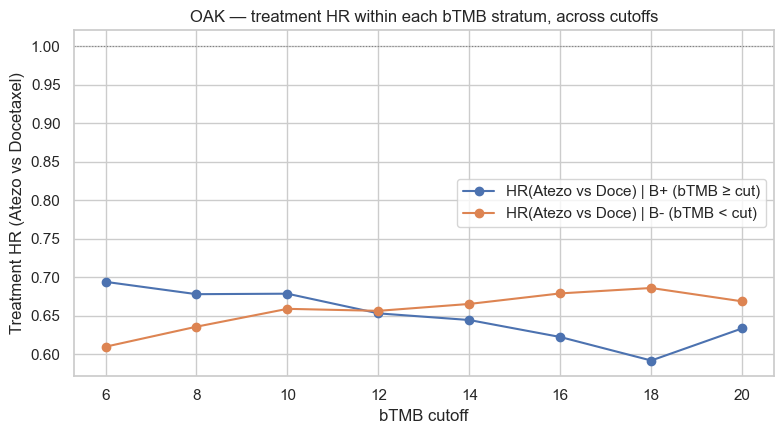

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
ax.plot(sweep.index, sweep["HR(Tx|B+)"], "-o", color="C0", label="HR(Atezo vs Doce) | B+ (bTMB ≥ cut)")
ax.plot(sweep.index, sweep["HR(Tx|B-)"], "-o", color="C1", label="HR(Atezo vs Doce) | B- (bTMB < cut)")
ax.set_xlabel("bTMB cutoff")
ax.set_ylabel("Treatment HR (Atezo vs Docetaxel)")
ax.set_title("OAK — treatment HR within each bTMB stratum, across cutoffs")
ax.legend()
plt.tight_layout()

## Combined POPLAR + OAK (as PBMF evaluates)

A quick read on the pooled cohort — the PBMF paper uses POPLAR+OAK together for training the biomarker score.

In [6]:
res = evaluate_biomarker(feat, label_col="btmb_ge16")
pd.DataFrame([res.as_series().rename("POPLAR+OAK, bTMB ≥ 16")])

,n_B+,n_B-,HR(Tx|B+),CI(Tx|B+),p(Tx|B+),HR(Tx|B-),CI(Tx|B-),p(Tx|B-),HR+/HR-,p(interaction)
"POPLAR+OAK, bTMB ≥ 16",223,630,0.588,"[0.43, 0.80]",0.000789,0.696,"[0.58, 0.84]",0.000128,0.844,0.286


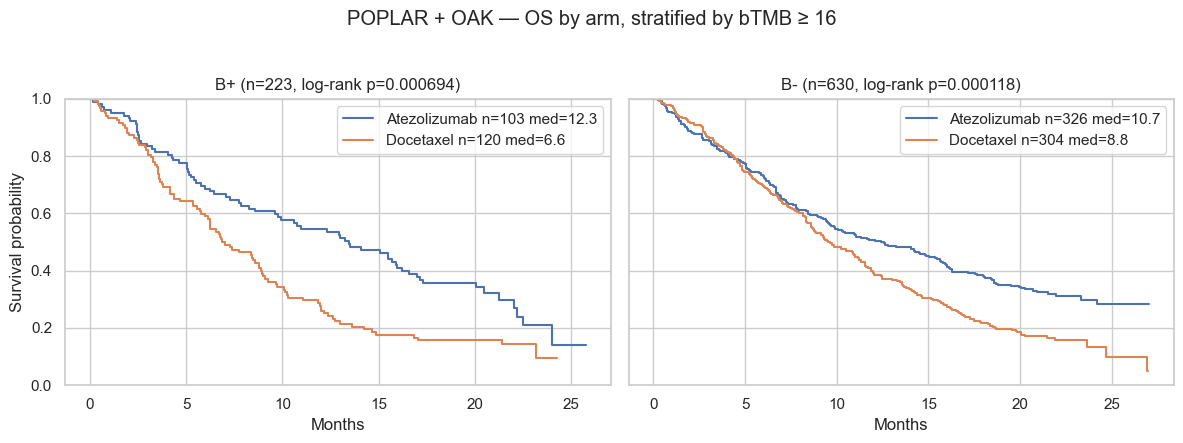

In [7]:
plot_km_strata(feat, label_col="btmb_ge16",
               title="POPLAR + OAK — OS by arm, stratified by bTMB ≥ 16")
plt.show()